# 4: Using LangGraph to Add Memory

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## Simple List of Messaged Memory System

In [3]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant. Answer all the questions to the best of your ability.",
        ),
        ("placeholder", "{messages}"),
    ]
)

model = ChatOpenAI(model="gpt-3.5-turbo")

chain = prompt | model

chain.invoke(
    {
        "messages": [
            (
                "human",
                "Translate this sentence from English to French: I love programming",
            ),
            ("ai", "J'adore programmer."),
            ("human", "What did you just say?"),
        ],
    }
)

AIMessage(content='I said "J\'adore programmer" in French, which means "I love programming" in English.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 59, 'total_tokens': 81, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CYdBqamju93ES8v62hO4rnzSccs9k', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--cce456f8-0a0d-4fca-b620-5b638aa5d46c-0', usage_metadata={'input_tokens': 59, 'output_tokens': 22, 'total_tokens': 81, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## Simple State Graph

In [25]:
# pip install langgraph
from typing import Annotated, TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    Messages have the type 'list'.
    The 'add_messages' function in the annotation defined how the state should be updated
    in this case it appends a new message to the list, rather than replacing the previous messages
    """
    messages : Annotated[list, add_messages]

builder = StateGraph(State)

In [26]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-3.5-turbo")

def chatbot(state: State):
    answer = model.invoke(state["messages"])
    return {"messages": [answer]}

builder.add_node("chatbot", chatbot)

In [27]:
builder.add_edge(START, 'chatbot')
builder.add_edge('chatbot', END)

graph = builder.compile()

In [28]:
graph_diagram = graph.get_graph().draw_mermaid_png()

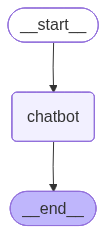

In [29]:
from IPython.display import Image, display
display(Image(graph_diagram))

In [30]:
from langchain_core.messages import HumanMessage

input = {
    "messages": [
        HumanMessage("hi"),
    ],
}
for chunk in graph.stream(input):
    print(chunk)

{'chatbot': {'messages': [AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CYkWlerao7MYlDUsxjW6fPQlJaEQN', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--f0f43893-1dcb-4027-8f89-2159f957a06f-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


## Adding Memory To StateGraph

In [45]:
from langgraph.checkpoint.memory import MemorySaver

# Add persistence with MemorySaver
graph = builder.compile(checkpointer=MemorySaver())

# Configure thread
thread1 = {
    "configurable": {
        "thread_id": "1",
    },
}

# Run with persistence
result_1 = graph.invoke(
    {
        "messages": [
            HumanMessage("hi, my name is Jack!"),
        ],
    },
    thread1,
)
print(result_1)

result_2 = graph.invoke(
    {
        "messages": [
            HumanMessage("what is my name?"),
        ],
    },
    thread1,
)
print(result_2)


# Get state
print(graph.get_state(thread1))

graph.update_state(thread1, {"messages": [HumanMessage("I like LLMs!")]})

print(graph.get_state(thread1))

{'messages': [HumanMessage(content='hi, my name is Jack!', additional_kwargs={}, response_metadata={}, id='9739b727-7c38-4250-9af9-f6f2881939dd'), AIMessage(content='Hello Jack! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 14, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CYkwCuZPPKFrvEH7IvxTxWbEMmx3r', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--25c9ca80-619a-4916-95ba-08cc8d87f36a-0', usage_metadata={'input_tokens': 14, 'output_tokens': 10, 'total_tokens': 24, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}
{'messages': [HumanMessage(

## Modifying Chat History



### Trimming Messages

In [46]:
from langchain_core.messages import SystemMessage, trim_messages, AIMessage
from langchain_openai import ChatOpenAI

trimmer = trim_messages(
    max_tokens=65,
    strategy="last",
    token_counter=ChatOpenAI(model="gpt-3.5-turbo"),
    include_system=True,
    allow_partial=False,
    start_on="human",
)

messages = [
    SystemMessage(content="you're a good assistant"),
    HumanMessage(content="hi! I'm bob"),
    AIMessage(content="hi!"),
    HumanMessage(content="I like vanilla ice cream"),
    AIMessage(content="nice"),
    HumanMessage(content="what's 2 + 2"),
    AIMessage(content="4"),
    HumanMessage(content="thanks"),
    AIMessage(content="no problem!"),
    HumanMessage(content="having fun?"),
    AIMessage(content="yes!"),
]

trimmer.invoke(messages)

[SystemMessage(content="you're a good assistant", additional_kwargs={}, response_metadata={}),
 HumanMessage(content="what's 2 + 2", additional_kwargs={}, response_metadata={}),
 AIMessage(content='4', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='thanks', additional_kwargs={}, response_metadata={}),
 AIMessage(content='no problem!', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='having fun?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='yes!', additional_kwargs={}, response_metadata={})]

### Filtering Messages

In [47]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, filter_messages

messages = [
    SystemMessage("you are a good assistant", id="1"),
    HumanMessage("example input", id="2", name="example_user"),
    AIMessage("example output", id="3", name="example_assistant"),
    HumanMessage("real input", id="4", name="bob"),
    AIMessage("real output", id="5", name="alice"),
]

filter_messages(messages, include_types="human")

[HumanMessage(content='example input', additional_kwargs={}, response_metadata={}, name='example_user', id='2'),
 HumanMessage(content='real input', additional_kwargs={}, response_metadata={}, name='bob', id='4')]

In [48]:
filter_messages(messages, exclude_names=["example_user", "example_assistant"])

[SystemMessage(content='you are a good assistant', additional_kwargs={}, response_metadata={}, id='1'),
 HumanMessage(content='real input', additional_kwargs={}, response_metadata={}, name='bob', id='4'),
 AIMessage(content='real output', additional_kwargs={}, response_metadata={}, name='alice', id='5')]

In [49]:
filter_messages(
    messages,
    include_types=[HumanMessage, AIMessage],
    exclude_ids=["3"],
)

[HumanMessage(content='example input', additional_kwargs={}, response_metadata={}, name='example_user', id='2'),
 HumanMessage(content='real input', additional_kwargs={}, response_metadata={}, name='bob', id='4'),
 AIMessage(content='real output', additional_kwargs={}, response_metadata={}, name='alice', id='5')]

In [51]:
model = ChatOpenAI(model="gpt-3.5-turbo")
filter_ = filter_messages(exclude_names=["example_user", "example_assistant"])
chain = filter_ | model

# chain.invoke(messages)

### Merging Consecutive Messages

In [ ]:
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    merge_message_runs,
)

messages = [
    SystemMessage("you're a good assistant."),
    SystemMessage("you always respond with a joke"),
    HumanMessage(
        [
            {"type": "text", "text": "i wonder why is it called langchain"},
        ],
    ),
    HumanMessage("and who is harrison chasing anyway"),
    AIMessage(
        """Well, I guess they thought "WordRope" and "SentenceString" just didn\'t have the same ring to it!"""
    ),
    AIMessage(
        """Why, he's probably chasing after the last cup of coffee in the office!"""
    ),
]

merge_message_runs(messages)

[SystemMessage(content="you're a good assistant.\nyou always respond with a joke", additional_kwargs={}, response_metadata={}),
 HumanMessage(content=[{'type': 'text', 'text': 'i wonder why is it called langchain'}, 'and who is harrison chasing anyway'], additional_kwargs={}, response_metadata={}),
 AIMessage(content='Well, I guess they thought "WordRope" and "SentenceString" just didn\'t have the same ring to it!\nWhy, he\'s probably chasing after the last cup of coffee in the office!', additional_kwargs={}, response_metadata={})]

In [78]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-3.5-turbo")
merger = merge_message_runs()
chain = merger | model